In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funcs import *
import scipy
import h5py, itertools
from scipy.fft import *
from nbodykit.lab import *

In [2]:
params=["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
param_path="/home/x-abairagi/ltu-cmass/params/latin_hypercube_params.txt"

In [15]:
np.loadtxt(param_path)[663]

array([0.3223 , 0.04625, 0.7015 , 0.9607 , 0.8311 ])

In [44]:
lhid=0
grid = 256
BoxSize=1000.0
voxel_size = np.array(3*[BoxSize/128])
MAS='CIC'
MAS_index=2
mass=h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['mass'][()].astype('float32')
mass=10**mass
pos = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype(np.float32)
pos=pos-0.5*BoxSize/128.
np.random.seed(0)
pos += np.random.uniform(-0.5*voxel_size, 0.5*voxel_size, pos.shape)
# pos += 0.5*voxel_size*np.random.randn(*pos.shape)/4
# pos=high_res_pos(pos, n=2)
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# Mass-weighted field
delta_mass=get_delta(pos=pos, grid=grid, W=1, mass=mass, BoxSize=1000.0, MAS=MAS, verbose=True)
k_m, Pk0_m, _, _ = compute_Pk(delta_mass, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)
# Cross-Spectrum
k_X, Pk0_X, _, _ = compute_XPk(delta_mass, delta, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
rk = Pk0_X/np.sqrt(Pk0*Pk0_m)

pos_target = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
# pos_target=high_res_pos(pos_target, n=2)
delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.029 seconds


Computing power spectrum of the field...
Time to complete loop = 0.62
Time taken = 0.85 seconds

Using CIC mass assignment scheme with weights
Time taken = 0.029 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.77 seconds

Computing power spectra of the fields...
Time FFTS = 0.47
Time loop = 0.38
Time taken = 0.85 seconds

Using CIC mass assignment scheme
Time taken = 0.031 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.77 seconds


In [6]:
lhid=0
grid = 256
BoxSize=1000.0
voxel_size = np.array(3*[BoxSize/128])
MAS='CIC'
MAS_index=2

pos_target = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
# pos_target=high_res_pos(pos_target, n=2)
delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# pos = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype(np.float32)
# pos=pos-0.5*BoxSize/128.
pos = h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
pos = NGP(pos, 128, BoxSize)

np.random.seed(0)
pos += np.random.uniform(-0.5*voxel_size, 0.5*voxel_size, pos.shape)
# pos += 0.5*voxel_size*np.random.randn(*pos.shape)/4
# Lnoise = (1000/128)/np.sqrt(3)  # Set by CHARM resolution
# pos += np.random.randn(*pos.shape) * Lnoise
# pos=high_res_pos(pos, n=2)

acc = pos_target-pos
pos = pos%BoxSize
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.032 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.77 seconds

Using CIC mass assignment scheme
Time taken = 0.032 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.77 seconds


In [208]:
ind= 110 #np.where(k<np.pi*grid/1000.)[0][-1]
k=k[:ind]
Pk0=Pk0[:ind]
# Pk0_m=Pk0_m[:ind]
k_target=k_target[:ind]
Pk0_target=Pk0_target[:ind]
# rk=rk[:ind]

In [30]:
k, Pk0 = caculate_Pk(delta_target, BoxSize=1000., MAS_index=2)

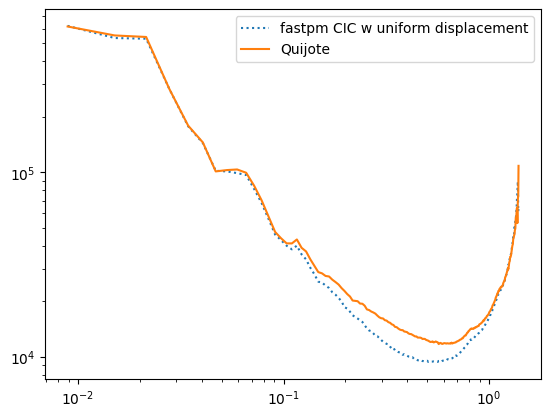

In [45]:
# plt.plot(k, Pk0_, '--',label='fastpm NGP w/o uniform displacement')
plt.plot(k, Pk0, ':', label='fastpm CIC w uniform displacement')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.loglog()
plt.legend()
# plt.ylim([1e2, 1e5])

Text(0, 0.5, '$r(k)$')

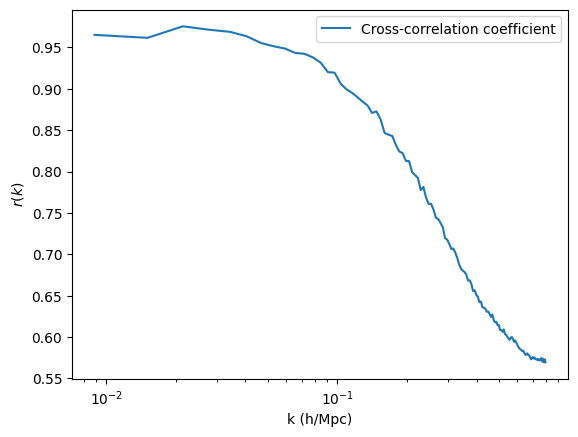

In [315]:
# plt.plot(k, Pk0, label='fastpm number density')
# plt.plot(k, Pk0_m-Pk0, label='fastpm mass-weighted')
# plt.plot(k, Pk0_X-Pk0, label='fastpm cross P(k)')
plt.plot(k, rk, label='Cross-correlation coefficient')
plt.semilogx()
plt.legend()
plt.xlabel("k (h/Mpc)")
plt.ylabel("$r(k)$")

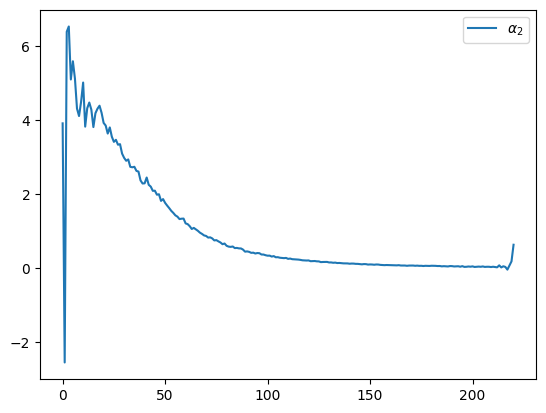

In [8]:
roots=get_roots(k, Pk0, Pk0_target)
# plt.plot(roots1[:,1].real, label='$\\alpha_1$')
plt.plot(roots[:,1].real, label='$\\alpha_2$')
# plt.loglog()
plt.legend()

In [46]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
delta_k = fftshift(fftn(delta)) #_mass

rad = np.zeros(3*[grid])
MAS_factor = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            rad[x,y,z]=np.sqrt(freq[x]**2+freq[y]**2+freq[z]**2)
            MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)

delta_k=np.multiply(MAS_factor,delta_k)
            
binlist = np.linspace(rad.min(), rad.max(), int(0.5*grid*np.sqrt(3)))
index = np.digitize(rad, binlist)-1

weights = roots[:,1].real[:int(0.5*grid*np.sqrt(3))] #*np.sqrt(Pk0/Pk0_m)
phi_k = weights[index]*delta_k

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize, threshold=1000./128)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.030 seconds


Using CIC mass assignment scheme
Time taken = 0.029 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.77 seconds


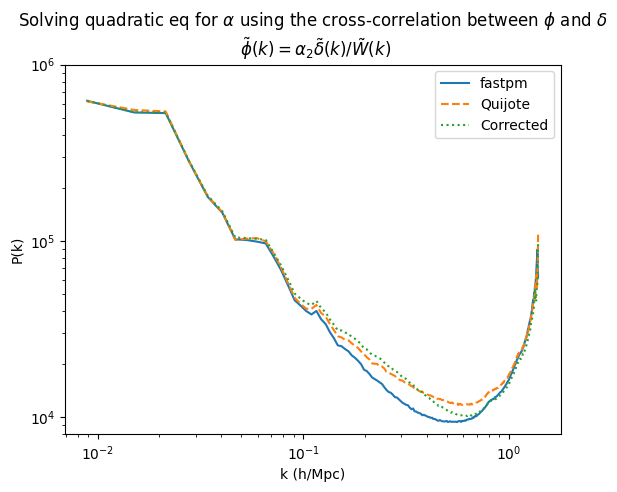

In [47]:
plt.plot(k, Pk0, label='fastpm')#'Quijote halos perturbed \n uniformly from the center of the voxel')
# plt.plot(k, Pk0, '--', label='Corrected-4th iter')
plt.plot(k_target, Pk0_target, '--', label='Quijote')# Nbody')
plt.plot(k_corrected, Pk0_corrected, ls=':', label='Corrected')
plt.loglog()
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.ylim([8e3,1e6])
plt.legend()


Using CIC mass assignment scheme
Time taken = 0.002 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.10 seconds

Using CIC mass assignment scheme
Time taken = 0.002 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds

Using CIC mass assignment scheme
Time taken = 0.002 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds


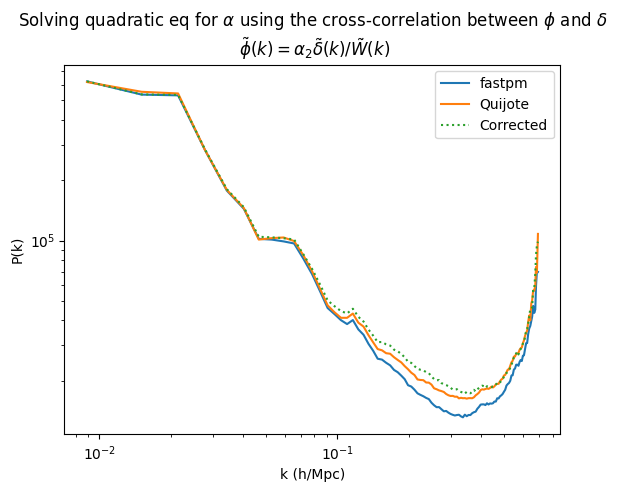

In [49]:
grid=128
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

plt.plot(k, Pk0, label='fastpm')#'Quijote halos perturbed \n uniformly from the center of the voxel')
plt.plot(k_target, Pk0_target, label='Quijote')# Nbody')
plt.plot(k_corrected, Pk0_corrected, ls=':', label='Corrected')
plt.loglog()
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
# plt.ylim([1,100000])
plt.legend()

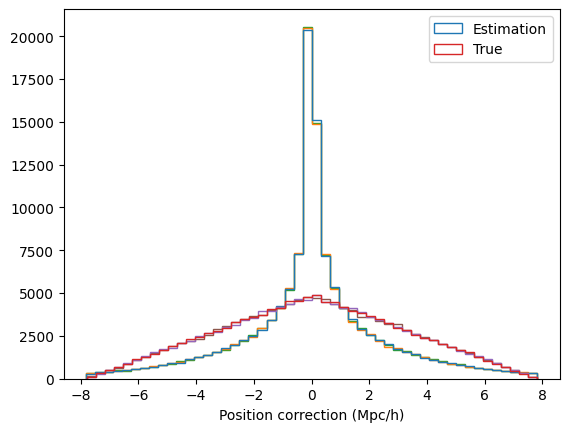

In [43]:
acc_partpos=acc_at_particle_pos(pos, a_x, a_y, a_z, grid=256, BoxSize=1000.)
acc_partpos[np.abs(acc_partpos)>1000./128]=0
plt.hist(acc_partpos,50, histtype='step', label='Estimation');
plt.hist(acc,50, histtype='step', label='True');
# plt.hist(pos_target-pos,50, histtype='step');
plt.xlabel("Position correction (Mpc/h)")
plt.legend()

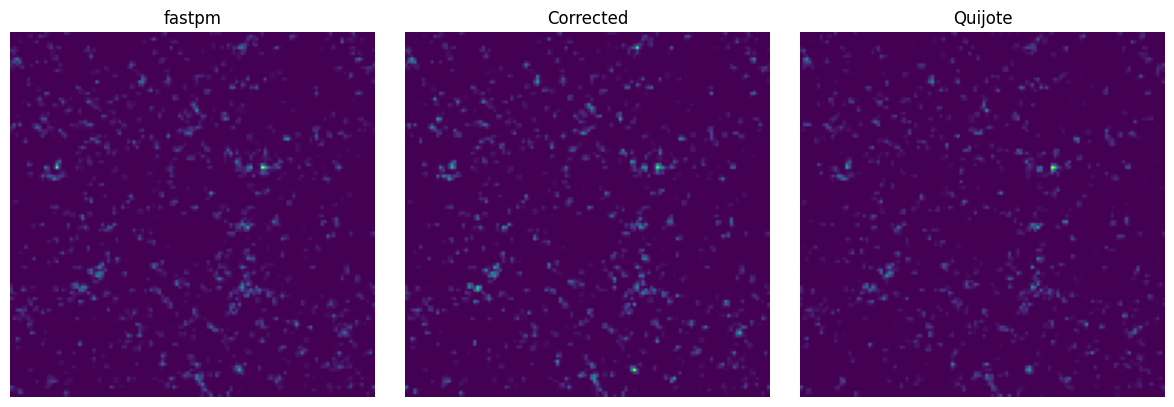

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# plt.imshow(delta[0])
ind=10
axes[0].imshow(delta[ind])
axes[0].set_title("fastpm")

axes[1].imshow(delta_corrected[ind])
axes[1].set_title("Corrected")

axes[2].imshow(delta_target[ind])
axes[2].set_title("Quijote")

for ax in axes:
    ax.axis("off")

plt.tight_layout()  # Adjust layout
plt.show()


In [42]:
Bk, Qk = compute_Bk(delta, grid, BoxSize, MAS='CIC', threads=1)

In [43]:
Bk_target, Qk_target = compute_Bk(delta_target, grid, BoxSize, MAS='CIC', threads=1)

In [44]:
Bk_corrected, Qk_corrected = compute_Bk(delta_corrected, grid, BoxSize, MAS='CIC', threads=1)

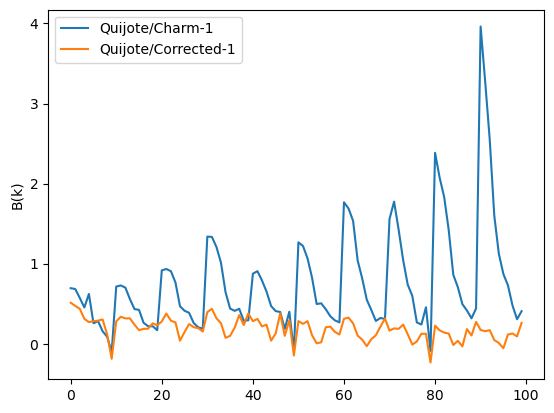

In [45]:
plt.plot(Bk_target[450:]/Bk[450:]-1, label="Quijote/Charm-1")
plt.plot(Bk_target[450:]/Bk_corrected[450:]-1, label="Quijote/Corrected-1")
plt.ylabel("B(k)")
# plt.xlim([200,500])
# plt.loglog()
plt.legend()

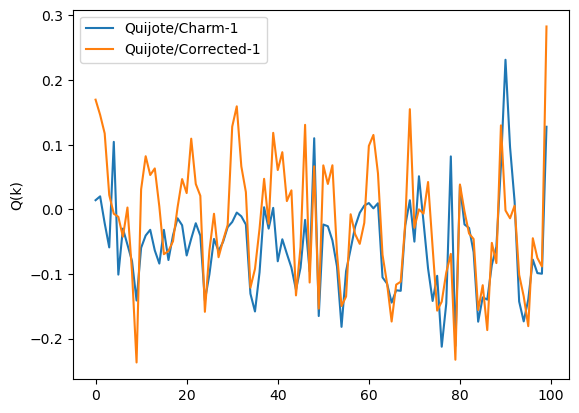

In [46]:
plt.plot(Qk_target[450:]/Qk[450:]-1, label="Quijote/Charm-1")
plt.plot(Qk_target[450:]/Qk_corrected[450:]-1, label="Quijote/Corrected-1")
plt.ylabel("Q(k)")
# plt.xlim([200,500])
# plt.loglog()
plt.legend()

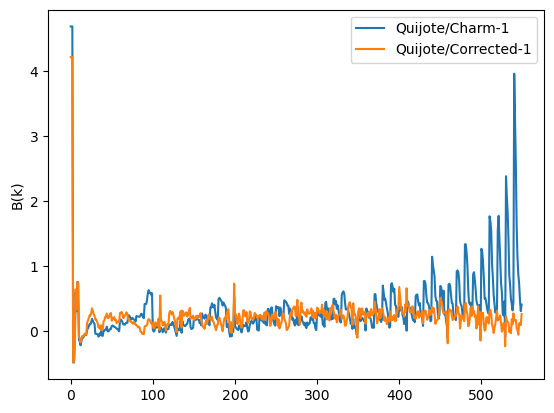

In [47]:
plt.plot(Bk_target/Bk-1, label="Quijote/Charm-1")
plt.plot(Bk_target/Bk_corrected-1, label="Quijote/Corrected-1")
plt.ylabel("B(k)")
plt.legend()

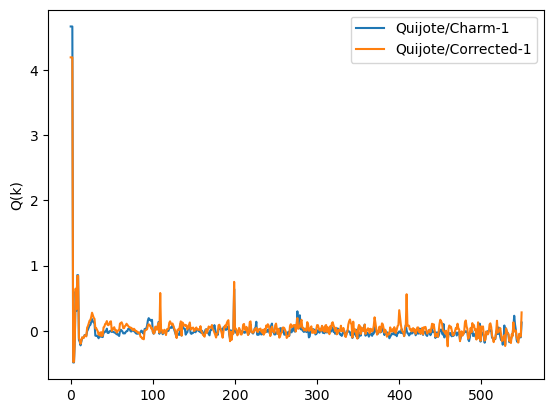

In [48]:
plt.plot(Qk_target/Qk-1, label="Quijote/Charm-1")
plt.plot(Qk_target/Qk_corrected-1, label="Quijote/Corrected-1")
plt.ylabel("Q(k)")
plt.legend()

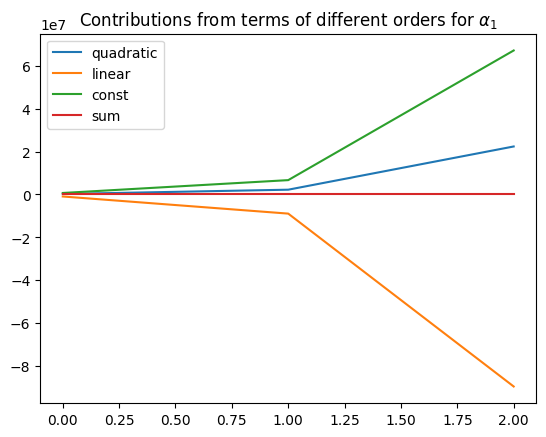

In [58]:
alpha=roots[:,1].real
plt.plot(alpha**2*a, label='quadratic')
plt.plot(alpha*b, label='linear')
plt.plot(c, label='const')
plt.plot(quadratic_eq(a,b,c,alpha), label='sum')
# plt.plot(alpha, label="alpha")
plt.title("Contributions from terms of different orders for $\\alpha_1$")
plt.legend()

In [15]:
def quadratic_eq(a,b,c, alpha):
    return (alpha**2*a+alpha*b+c)
quadratic_eq(a,b,c,roots[:,1].real)

array([ 0.00000000e+00, -1.13686838e-13,  4.54747351e-13, -4.54747351e-13,
        0.00000000e+00,  4.54747351e-13,  2.27373675e-13,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  4.54747351e-13, -4.54747351e-13,
        0.00000000e+00,  0.00000000e+00, -4.54747351e-13,  0.00000000e+00,
        0.00000000e+00,  4.54747351e-13,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        4.54747351e-13, -4.54747351e-13,  0.00000000e+00,  0.00000000e+00,
       -4.54747351e-13,  0.00000000e+00, -4.54747351e-13,  4.54747351e-13,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -9.09494702e-13,  4.54747351e-13,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -4.54747351e-13, -4.54747351e-13, -4.54747351e-13,
        0.00000000e+00,  0.00000000e+00, -4.54747351e-13,  4.54747351e-13,
        9.09494702e-13,  0.00000000e+00, -4.54747351e-13,  0.00000000e+00,
       -9.09494702e-13, -

In [22]:
alpha=roots[:,0].real
# .reshape(len(k),-1)

In [133]:
discriminator = np.sqrt(b**2-4*a*c)
alpha1 = (-b+discriminator)/(2*a)
alpha2 = (-b-discriminator)/(2*a)

In [43]:
c

array([  -233730.74354638,  -2230205.0535811 , -22380612.88390167])

In [123]:
b**2-4*a*c

array([9.57454746e+03, 6.30649174e+04, 2.48541147e+05, 1.91848404e+05,
       1.78385405e+05, 2.26707518e+05, 1.95537625e+05, 3.35939672e+05,
       5.36419130e+05, 7.40618215e+05, 7.64885604e+05, 7.43068873e+05,
       6.73278844e+05, 6.19188487e+05, 6.90318479e+05, 7.80200649e+05,
       9.87015617e+05, 1.36143141e+06, 1.36722249e+06, 1.52752852e+06,
       1.51665979e+06, 1.54462194e+06, 1.58017996e+06, 1.81111022e+06,
       1.99291881e+06, 2.29638214e+06, 2.46555553e+06, 2.67626767e+06,
       2.88887343e+06, 3.02373669e+06, 3.21275311e+06, 3.37335550e+06,
       3.59229768e+06, 3.65879250e+06, 4.06549777e+06, 4.51283218e+06,
       4.73654099e+06, 5.26310291e+06, 5.56586574e+06, 5.59162552e+06,
       6.10351959e+06, 6.46101582e+06, 6.97126750e+06, 7.42188778e+06,
       7.73527532e+06, 8.10400739e+06, 8.62319148e+06, 9.32280807e+06,
       9.75410903e+06, 1.04478202e+07, 1.08746456e+07, 1.15931930e+07,
       1.20547952e+07, 1.27974482e+07, 1.31601534e+07, 1.40294514e+07,
      

In [141]:
grid=4
BoxSize=4.
MAS='CIC'
iterables=np.arange(4)
pos=[]
for i in itertools.product(iterables[1:], iterables[2:], [0,1,3]):
    pos.append(i)
pos=np.array(pos).astype(np.float32)

In [190]:
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.002 seconds


Computing power spectrum of the field...
Time to complete loop = 0.07
Time taken = 0.09 seconds


In [194]:
delta_k=FFT_physical(pos[:100], grid, BoxSize)*grid**3/BoxSize**3
# k, Pk0 = caculate_Pk_from_delta_k(delta_k, BoxSize, MAS_index=2)

In [ ]:
k

In [151]:
MAS_index=2
MAS_factor = np.zeros(3*[grid])
freq = fftshift(fftfreq(grid, BoxSize/grid))
# delta_k=fftshift(fftn(delta))
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            # MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)
            MAS_factor[x,y,z]=MAS_correction(2*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(2*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(2*BoxSize*freq[z]/grid, MAS_index)

# delta_k=np.multiply(MAS_factor,delta_k)
phi_k = 0.1*delta_k

In [152]:
phi_k/delta_k

/tmp/ipykernel_2614053/150963149.py:1: RuntimeWarning: invalid value encountered in divide
  phi_k/delta_k


array([[[0.1       +0.0000000e+00j, 0.1       -0.0000000e+00j,
         0.1       -0.0000000e+00j, 0.1       -0.0000000e+00j],
        [0.1       -0.0000000e+00j, 0.1       +0.0000000e+00j,
         0.10000001+0.0000000e+00j, 0.1       +0.0000000e+00j],
        [0.1       +7.4446255e-24j, 0.1       -0.0000000e+00j,
         0.10000001+2.4815418e-24j, 0.1       -0.0000000e+00j],
        [0.1       -0.0000000e+00j, 0.1       +0.0000000e+00j,
         0.10000001+0.0000000e+00j, 0.1       +0.0000000e+00j]],

       [[0.09999999-0.0000000e+00j, 0.1       -0.0000000e+00j,
         0.09999999+0.0000000e+00j, 0.10000001-0.0000000e+00j],
        [0.1       -0.0000000e+00j, 0.1       +0.0000000e+00j,
         0.10000001+0.0000000e+00j, 0.1       +0.0000000e+00j],
        [0.1       +0.0000000e+00j, 0.1       -0.0000000e+00j,
         0.10000001-0.0000000e+00j, 0.1       -0.0000000e+00j],
        [0.1       -0.0000000e+00j, 0.1       +0.0000000e+00j,
         0.10000001+0.0000000e+00j, 0.1       

In [125]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
rx, ry, rz = np.meshgrid(freq, freq, freq, indexing='ij')
rad = np.sqrt(rx**2+ry**2+rz**2)

binlist = np.linspace(rad.min(), rad.max(), len(k))
index = np.digitize(rad, binlist)-1

weights = np.array([0, 0.2, 0.2])
# weights = np.concatenate([roots[:,1].real,0.2*np.zeros(95)])
phi_k = weights[index]*delta_k

In [172]:
a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
acc_partpos=acc_at_particle_pos(pos, a_x, a_y, a_z, grid, BoxSize)
pos_target = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

# delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
# k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

In [195]:
delta_k_target=FFT_physical(pos_target[:100], grid, BoxSize)*grid**3/BoxSize**3
# k_target, Pk0_target = caculate_Pk_from_delta_k(delta_k_target, BoxSize, MAS_index=2)

In [197]:
acc_partpos=acc[:100]

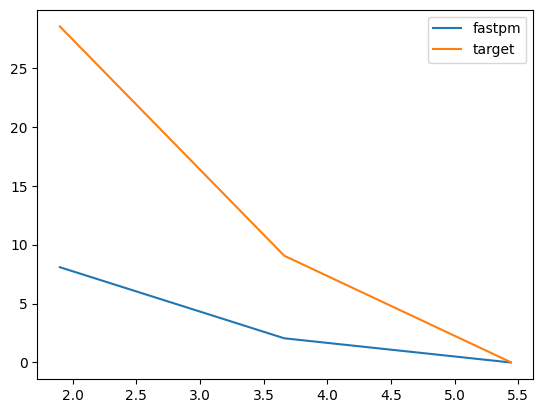

In [154]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='target')
# plt.loglog()
plt.legend()

In [17]:
delta_k=fftshift(fftn(delta))
delta_k=np.multiply(MAS_factor,delta_k)
delta_k_target=fftshift(fftn(delta_target))
delta_k_target=np.multiply(MAS_factor,delta_k_target)

In [208]:
# (delta_k_target-delta_k-(2*np.pi*rad)**2*phi_k).astype(np.float16)*BoxSize**3/grid**3
(delta_k_target-delta_k).astype(np.float16)

/tmp/ipykernel_2614053/2528965418.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  (delta_k_target-delta_k).astype(np.float16)
/tmp/ipykernel_2614053/2528965418.py:2: RuntimeWarning: overflow encountered in cast
  (delta_k_target-delta_k).astype(np.float16)


array([[[    inf,     inf,     inf, ...,  53088.,  15136.,  -3050.],
        [    inf,     inf,     inf, ..., -52672.,    -inf,    -inf],
        [    inf,     inf,     inf, ...,    -inf,    -inf,    -inf],
        ...,
        [-56384.,    -inf,    -inf, ...,     inf,     inf,     inf],
        [-60992.,    -inf,    -inf, ...,     inf,     inf,  46080.],
        [   -inf,    -inf,    -inf, ...,     inf,     inf,  -5280.]],

       [[    inf,     inf,     inf, ..., -59712.,    -inf, -57216.],
        [    inf,     inf,     inf, ...,    -inf,    -inf,    -inf],
        [    inf,     inf,     inf, ...,    -inf,    -inf,    -inf],
        ...,
        [   -inf,    -inf,    -inf, ...,     inf,  60832., -43072.],
        [   -inf,    -inf,    -inf, ...,     inf, -13664.,    -inf],
        [   -inf,    -inf,    -inf, ...,  20656.,    -inf,    -inf]],

       [[    inf,     inf,     inf, ...,    -inf,    -inf, -44960.],
        [    inf,     inf,     inf, ...,    -inf,    -inf,    -inf],
    

In [211]:
((delta_k_target-delta_k)*BoxSize**3/grid**3-T2-T3).astype(np.float16)
# I.astype(np.float16)#*BoxSize**3/grid**3

/tmp/ipykernel_2614053/845143241.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  ((delta_k_target-delta_k)*BoxSize**3/grid**3-T2-T3).astype(np.float16)
/tmp/ipykernel_2614053/845143241.py:1: RuntimeWarning: overflow encountered in cast
  ((delta_k_target-delta_k)*BoxSize**3/grid**3-T2-T3).astype(np.float16)


array([[[ inf,  inf,  inf, ...,  inf,  inf, -inf],
        [ inf,  inf,  inf, ..., -inf, -inf, -inf],
        [ inf,  inf,  inf, ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf, ...,  inf,  inf,  inf],
        [-inf, -inf, -inf, ...,  inf,  inf,  inf],
        [-inf, -inf, -inf, ...,  inf,  inf, -inf]],

       [[ inf,  inf,  inf, ..., -inf, -inf, -inf],
        [ inf,  inf,  inf, ..., -inf, -inf, -inf],
        [ inf,  inf,  inf, ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf, ...,  inf,  inf, -inf],
        [-inf, -inf, -inf, ...,  inf, -inf, -inf],
        [-inf, -inf, -inf, ...,  inf, -inf, -inf]],

       [[ inf,  inf,  inf, ..., -inf, -inf, -inf],
        [ inf,  inf,  inf, ..., -inf, -inf, -inf],
        [ inf,  inf,  inf, ..., -inf, -inf, -inf],
        ...,
        [-inf, -inf, -inf, ...,  inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf],
        [-inf, -inf, -inf, ..., -inf, -inf, -inf]],

       ...,

       [[-inf, -inf, -in

In [215]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
T2=np.zeros(3*[grid]).astype(np.complex64)
for i0, ki in enumerate(freq):
    for j0, kj in enumerate(freq):
        for k0, kk in enumerate(freq): 
            s_exp=0
            for ind, pos_i in enumerate(pos[:100]):
                s_exp+=np.exp(-2j*np.pi*(ki*pos_i[0]+kj*pos_i[1]+kk*pos_i[2])) * 2*np.pi*(ki*acc_partpos[ind,0]+kj*acc_partpos[ind,1]+kk*acc_partpos[ind,2])                        
            T2[i0,j0,k0]=s_exp

T2=-1j*BoxSize**3*T2/pos[:100].shape[0]

T3=np.zeros(3*[grid]).astype(np.complex64)
for i0, ki in enumerate(freq):
    for j0, kj in enumerate(freq):
        for k0, kk in enumerate(freq): 
            s_exp=0
            for ind, pos_i in enumerate(pos[:100]):
                s_exp+=np.exp(-2j*np.pi*(ki*pos_i[0]+kj*pos_i[1]+kk*pos_i[2])) * (2*np.pi*(ki*acc_partpos[ind,0]+kj*acc_partpos[ind,1]+kk*acc_partpos[ind,2])**2)                       
            T3[i0,j0,k0]=s_exp

T3=-0.5j*BoxSize**3*T3/pos[:100].shape[0]

In [178]:
I=np.zeros(3*[grid]).astype(np.complex64)
for i0, ki in enumerate(freq):
    for j0, kj in enumerate(freq):
        for k0, kk in enumerate(freq): 
            
            s=0
            for i, qi in enumerate(freq):
                for j, qj in enumerate(freq):
                    for k1, qk in enumerate(freq):
                        s_exp=0
                        for pos_i in pos:
                            s_exp+=np.exp(-2j*np.pi*((ki-qi)*pos_i[0]+(kj-qj)*pos_i[1]+(kk-qk)*pos_i[2]))
                        s += (2*np.pi)**2*(ki*qi+kj*qj+kk*qk)*phi_k[i,j,k1]*s_exp
                        
            I[i0,j0,k0]=s
I=I/pos.shape[0]

In [76]:
s=FFT_physical(pos_target, grid, BoxSize)
(s-delta_k_target*BoxSize**3/grid**3).astype(np.float16)

/tmp/ipykernel_2614053/2069312309.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  (s-delta_k_target*BoxSize**3/grid**3).astype(np.float16)


array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]], dtype=float16)

In [50]:
delta=np.ones([4,4,4]).astype(np.float32)
delta[1,1,1]=0
delta[2,1,1]=2
delta_target=np.ones([4,4,4]).astype(np.float32)
delta_target[1,1,1]=0.5
delta_target[2,1,1]=1.5
delta=delta/delta.mean()-1
delta_target=delta_target/delta_target.mean()-1

In [40]:
delta_k=fftshift(fftn(delta))
# delta_k[35:95, 35:95, 35:95]=0
# delta_k_=delta_k
# delta=ifftn(ifftshift(delta_k)).real
# delta_k=fftshift(fftn(delta))


Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds


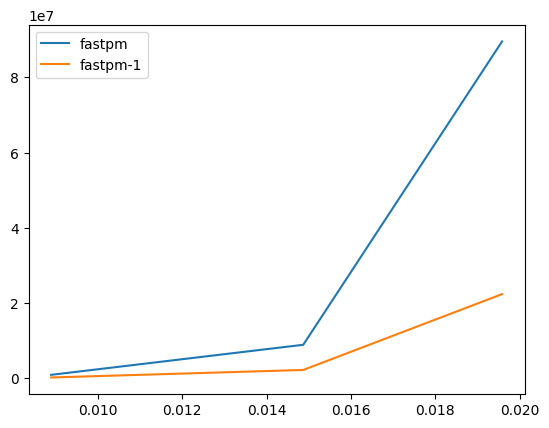

In [52]:
# delta=ifftn(ifftshift(delta_k)).real
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)
# k, Pk0 = caculate_Pk_from_delta_k(delta_k, grid=128, BoxSize=1000., MAS_index=2)

k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='fastpm-1')
# plt.loglog()
plt.legend()

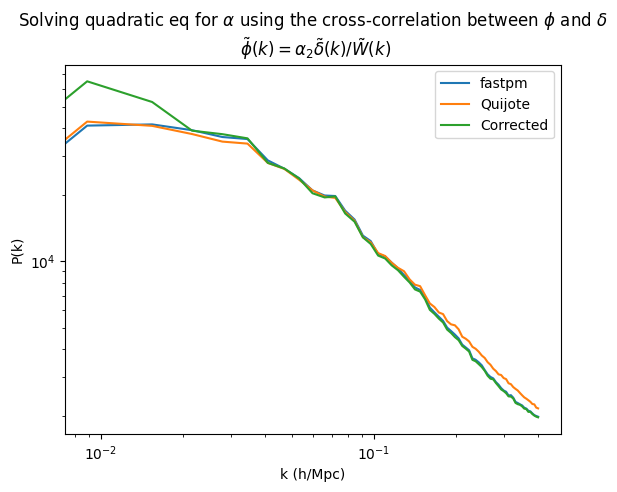

In [137]:
compensated=True
interlaced=True
MAS='cic'
delta=get_delta_nbodykit(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta, mode='1d')
Pk0 = r.power

delta_target=get_delta_nbodykit(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=True)
r = FFTPower(delta_target, mode='1d')
Pk0_target = r.power

delta_corrected=get_delta_nbodykit(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta_corrected, mode='1d')
Pk0_corrected = r.power

plt.plot(Pk0['k'], Pk0['power'].real, label='fastpm')
plt.plot(Pk0_target['k'], Pk0_target['power'].real, label='Quijote')
plt.plot(Pk0_corrected['k'], Pk0_corrected['power'].real, label='Corrected')
plt.loglog()
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
# plt.ylim([1,100000])
plt.legend()

In [138]:
k_QuiXFPM, Pk0_QuiXFPM, _, _ = compute_XPk(delta_target, delta, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
rk_QuiXFPM = Pk0_QuiXFPM/np.sqrt(Pk0_target*Pk0)

k_QuiXcorrected, Pk0_QuiXcorrected, _, _ = compute_XPk(delta_target, delta_corrected, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
rk_QuiXcorrected = Pk0_QuiXcorrected/np.sqrt(Pk0_target*Pk0_corrected)


Computing power spectra of the fields...


TypeError: object of type 'RealField' has no len()

Text(0, 0.5, 'Cross Correlation Coefficient $r(k)$')

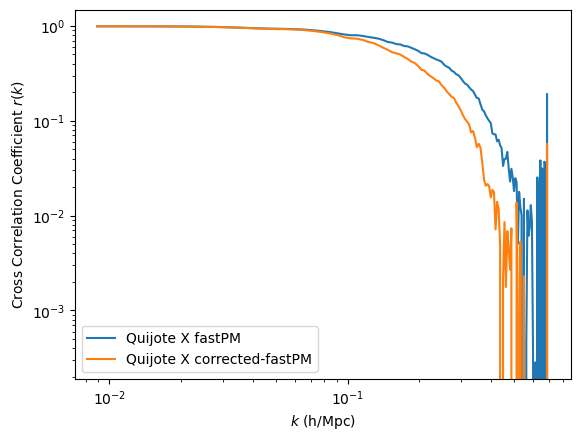

In [40]:
plt.plot(k_QuiXFPM, rk_QuiXFPM, label="Quijote X fastPM")
plt.plot(k_QuiXcorrected, rk_QuiXcorrected, label="Quijote X corrected-fastPM")
plt.loglog()
plt.legend()
plt.xlabel("$k$ (h/Mpc)")
plt.ylabel("Cross Correlation Coefficient $r(k)$")